<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1945 | Val: 472 | Test: 90


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[EfficientNet-B0] Epoch   1/100 | LR: 1.00e-04 | train loss 1.1782 acc 0.535 | val loss 0.7997 acc 0.648 *


[EfficientNet-B0] Epoch   2/100 | LR: 1.00e-04 | train loss 0.7019 acc 0.687 | val loss 0.5715 acc 0.750 *


[EfficientNet-B0] Epoch   3/100 | LR: 1.00e-04 | train loss 0.5712 acc 0.741 | val loss 0.5238 acc 0.778 *


[EfficientNet-B0] Epoch   4/100 | LR: 1.00e-04 | train loss 0.4684 acc 0.789 | val loss 0.4710 acc 0.797 *


...

[EfficientNet-B0] Epoch  15/100 | LR: 1.00e-05 | train loss 0.1945 acc 0.903 | val loss 0.4842 acc 0.843


[EfficientNet-B0] Epoch  16/100 | LR: 1.00e-05 | train loss 0.1651 acc 0.919 | val loss 0.4081 acc 0.854


[EfficientNet-B0] Epoch  17/100 | LR: 1.00e-05 | train loss 0.1541 acc 0.934 | val loss 0.4242 acc 0.852


[EfficientNet-B0] Epoch  18/100 | LR: 1.00e-05 | train loss 0.1388 acc 0.933 | val loss 0.4282 acc 0.860


[EfficientNet-B0] Epoch  19/100 | LR: 1.00e-05 | train loss 0.1358 acc 0.934 | val loss 0.4071 acc 0.856

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 19.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.3936)


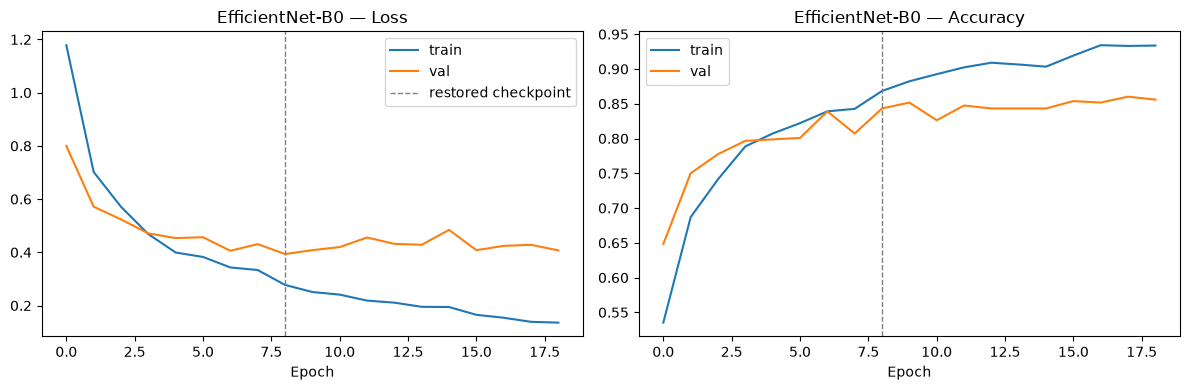

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.844


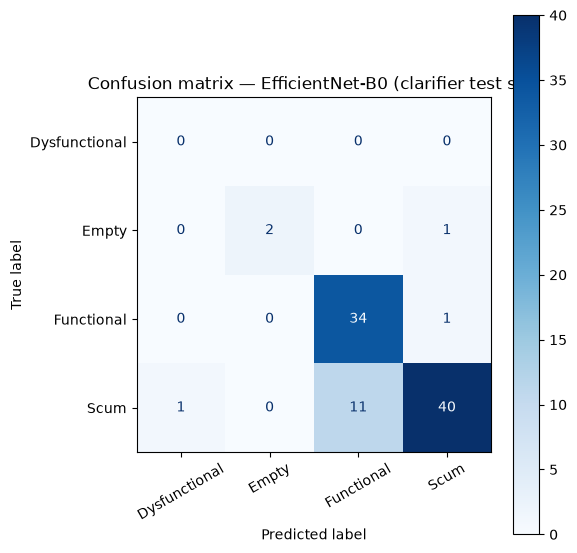

               precision    recall  f1-score   support

Dysfunctional      0.000     0.000     0.000         0
        Empty      1.000     0.667     0.800         3
   Functional      0.756     0.971     0.850        35
         Scum      0.952     0.769     0.851        52

     accuracy                          0.844        90
    macro avg      0.677     0.602     0.625        90
 weighted avg      0.877     0.844     0.849        90

  [warn] 'Dysfunctional' has 0 examples in this test set — AUC undefined, skipping.


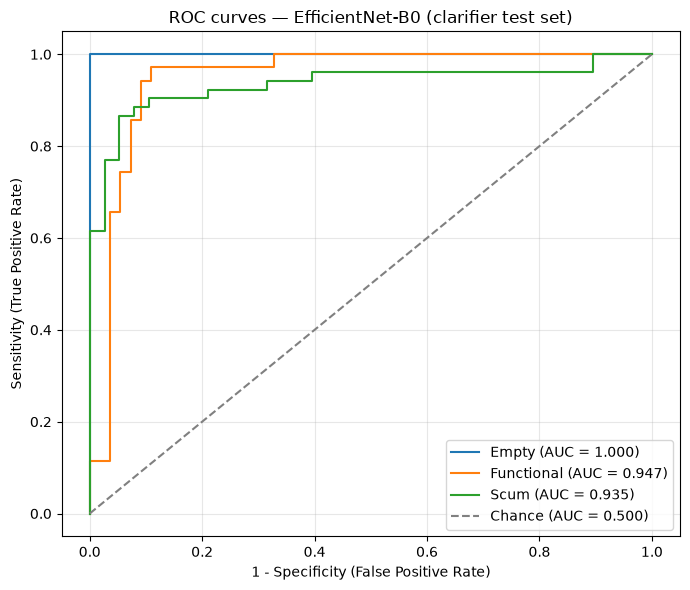

AUC (area under ROC curve) per class:
  Dysfunctional  : undefined (0 examples)
  Empty          : 1.000
  Functional     : 0.947
  Scum           : 0.935

Mean AUC (over 3/4 classes with test examples): 0.961


(np.float64(0.8444444444444444),
 {'Dysfunctional': nan,
  'Empty': 1.0,
  'Functional': 0.9470129870129871,
  'Scum': 0.9352226720647773})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/results_clarifier_efficientnet_b0_Atlantis.pkl


Saved model weights to ../models/clarifier_efficientnet_b0_cnn.pt
